# Copula Fitting
 
**Stage:** Joint dependence modelling — fit and compare Gaussian and Student-t copulas

## Objectives
1. Load uniform marginals from Notebook 02
2. Visualise joint dependence structure via scatter plots and chi-plots
3. Fit Gaussian copula — symmetric, no tail dependence (benchmark)
4. Fit Student-t copula — symmetric tail dependence (main model)
5. Compare copulas using AIC/BIC and log-likelihood
6. Compute tail dependence coefficients
7. Visualise copula fit quality
8. Save fitted copulas for Notebook 04 — Monte Carlo VaR Simulation

In [12]:
import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as stats_scipy
from scipy.stats import norm, t as student_t

from src.copula_utils import GaussianCopula, StudentTCopula, compare_copulas

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [3]:
#Loading Uniform Marginals
uniforms = pd.read_csv('../data/raw/uniform_marginals.csv', 
                       index_col='Date', parse_dates=True)

print(f"Shape:      {uniforms.shape}")
print(f"Date range: {uniforms.index[0].date()} to {uniforms.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(uniforms.head())
print(f"\nDescriptive stats:")
print(uniforms.describe().round(4))

Shape:      (3280, 3)
Date range: 2010-01-06 to 2022-12-30

First 5 rows:
             FTSE100    GBPUSD     Brent
Date                                    
2010-01-06  0.555354  0.623401  0.810310
2010-01-07  0.461992  0.165168  0.391616
2010-01-08  0.560610  0.845694  0.443273
2010-01-11  0.528694  0.797908  0.366148
2010-01-12  0.158905  0.787398  0.100569

Descriptive stats:
         FTSE100     GBPUSD      Brent
count  3280.0000  3280.0000  3280.0000
mean      0.5000     0.4999     0.4979
std       0.2629     0.2661     0.2568
min       0.0002     0.0000     0.0003
25%       0.2846     0.2831     0.2970
50%       0.5145     0.5042     0.5060
75%       0.7123     0.7141     0.7031
max       0.9982     0.9995     0.9997


### Sklar's Theorem 

Any joint distribution $H(x_1, x_2, x_3)$ can be decomposed as:

$$H(x_1, x_2, x_3) = C(F_1(x_1), F_2(x_2), F_3(x_3))$$

where $F_i$ are the marginal CDFs and $C$ is a copula function.

This means dependence structure and marginal behaviour are completely 
separable. In Notebook 02 we estimated $F_i$ via GJR-GARCH and obtained 
uniform marginals $u_i = F_i(x_i)$. Here we fit $C(u_1, u_2, u_3)$ — 
the copula — to model how the assets move together.

**Why this matters for risk management**

A portfolio VaR model must answer: given that FTSE crashes, how likely 
is it that Brent and GBP/USD also crash simultaneously? This is a question 
about dependence structure — exactly what the copula captures.

**Copulas fitted in this notebook**
| Copula | Tail Dependence | Parameters |
|--------|----------------|------------|
| Gaussian | None ($\lambda_L = \lambda_U = 0$) | Correlation matrix $R$ |
| Student-t | Symmetric ($\lambda_L = \lambda_U > 0$) | $R$ + degrees of freedom $\nu$ |

The Gaussian copula is the benchmark — it is what many financial 
institutions used before 2008. Its failure to capture tail dependence 
contributed to the underestimation of systemic risk during the crisis.

### 1. Visual Exploration of Joint Dependence

Before fitting any model, we visualise the joint distribution of the 
uniform marginals. Under a Gaussian copula, scatter plots of 
$(u_i, u_j)$ should show uniform spread with no corner clustering. 
Under a Student-t copula, we expect clustering in the corners — 
i.e. extreme values tend to occur together.

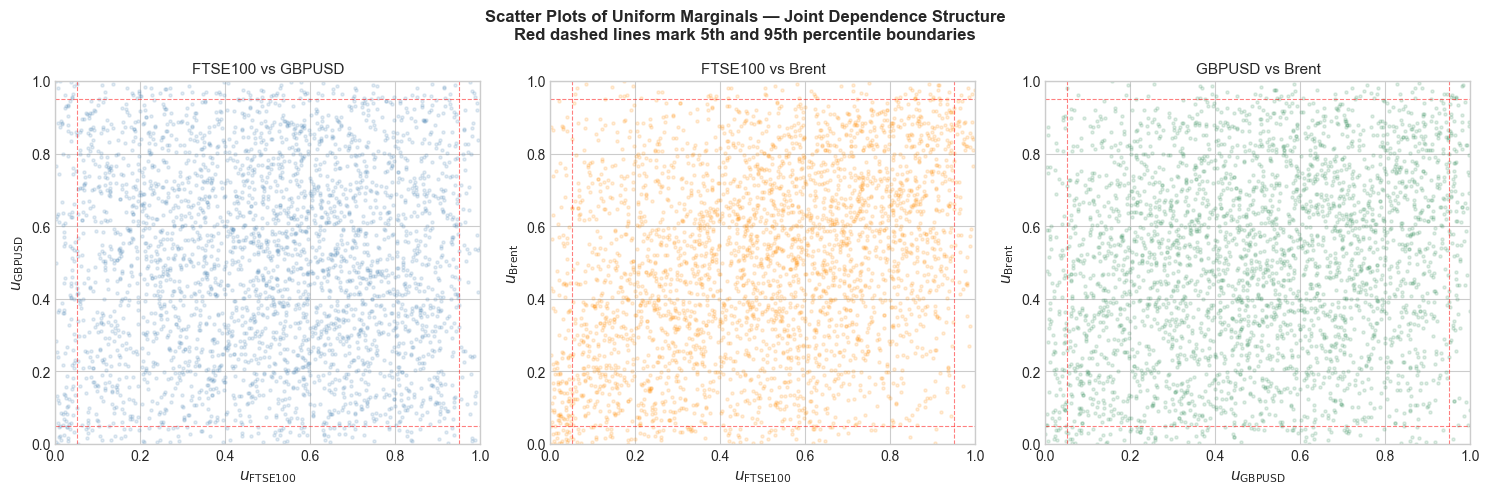

In [4]:
pairs = [('FTSE100', 'GBPUSD'), ('FTSE100', 'Brent'), ('GBPUSD', 'Brent')]
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (a, b) in enumerate(pairs):
    axes[i].scatter(uniforms[a], uniforms[b], 
                    alpha=0.15, s=5, color=colors[i])
    axes[i].set_xlabel(f'$u_{{\\mathrm{{{a}}}}}$', fontsize=11)
    axes[i].set_ylabel(f'$u_{{\\mathrm{{{b}}}}}$', fontsize=11)
    axes[i].set_title(f'{a} vs {b}', fontsize=11)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    
    # Highlight extreme quantile region (corners)
    axes[i].axvline(0.05, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].axvline(0.95, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].axhline(0.05, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[i].axhline(0.95, color='red', linewidth=0.8, linestyle='--', alpha=0.5)

plt.suptitle('Scatter Plots of Uniform Marginals — Joint Dependence Structure\n'
             'Red dashed lines mark 5th and 95th percentile boundaries',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/09_uniform_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights on Joint Dependence Structure

Under a Gaussian copula, points should be spread uniformly across the 
entire $[0,1]^2$ square with no corner clustering. Under a Student-t 
copula, we expect excess mass in the bottom-left corner (joint crashes) 
and top-right corner (joint rallies) relative to the Gaussian prediction.

**FTSE100 vs GBP/USD**
- Points appear relatively dispersed across the square — consistent with 
  the low average correlation of 0.089 from the heatmap
- Some visible clustering in the bottom-left corner — days where both 
  FTSE and GBP/USD simultaneously experienced extreme losses
- The near-independence in the centre but dependence in the tails is 
  precisely the pattern a Student-t copula captures and Gaussian misses

**FTSE100 vs Brent**
- Noticeably more structured scatter than the FTSE/GBP pair — consistent 
  with the stronger average correlation of 0.340
- Clear tendency for points to cluster along a positive diagonal, 
  particularly visible in the lower-left and upper-right corners
- This confirms that FTSE and Brent tend to crash and rally together

**GBP/USD vs Brent**
- Moderate positive dependence visible, consistent with correlation of 0.173
- Corner clustering is present but less pronounced than FTSE/Brent

**Key observation**
All three pairs show excess corner mass relative to what a uniform scatter 
would predict — particularly in the bottom-left (joint crash) corner. 
This is visual evidence of positive tail dependence that the Gaussian 
copula cannot capture. We quantify this formally in the next section.

### 2. Corner Concentration Analysis 
We formally quantify tail clustering by measuring the proportion of 
observations that simultaneously fall in the extreme tails of both assets.

Under a Gaussian copula with zero tail dependence, the expected proportion 
of joint observations below the 5th percentile of both assets is simply:

$$P(U_i < 0.05 \cap U_j < 0.05) = 0.05 \times 0.05 = 0.0025$$

Any proportion significantly above 0.0025 is evidence of tail dependence 
that the Gaussian copula cannot capture.


In [5]:
print("Corner Concentration Analysis")
print("Proportion of observations in joint tail regions\n")
print(f"{'Pair':<22} {'Lower-Lower':>13} {'Upper-Upper':>13} {'Expected (Gaussian)':>20}")
print("-" * 72)

threshold = 0.05

for a, b in pairs:
    ll = ((uniforms[a] < threshold) & (uniforms[b] < threshold)).mean()
    uu = ((uniforms[a] > 1-threshold) & (uniforms[b] > 1-threshold)).mean()
    expected = threshold ** 2
    print(f"{a+' / '+b:<22} {ll:>13.4f} {uu:>13.4f} {expected:>20.4f}")

print(f"\nUnder Gaussian copula, expected proportion = 0.05² = {threshold**2:.4f}")
print("Values above 0.0025 indicate positive tail dependence")

Corner Concentration Analysis
Proportion of observations in joint tail regions

Pair                     Lower-Lower   Upper-Upper  Expected (Gaussian)
------------------------------------------------------------------------
FTSE100 / GBPUSD              0.0043        0.0012               0.0025
FTSE100 / Brent               0.0058        0.0015               0.0025
GBPUSD / Brent                0.0034        0.0021               0.0025

Under Gaussian copula, expected proportion = 0.05² = 0.0025
Values above 0.0025 indicate positive tail dependence


**Lower-left tail (joint crashes)**
- FTSE100 / Brent shows the strongest lower tail dependence — joint crashes 
  occur at **2.3× the frequency** the Gaussian copula predicts (0.0058 vs 0.0025)
- FTSE100 / GBPUSD shows **1.7×** the expected frequency (0.0043 vs 0.0025)
- GBPUSD / Brent shows **1.4×** the expected frequency (0.0034 vs 0.0025)
- All three pairs show excess lower tail mass — simultaneous crashes are 
  systematically more common than the Gaussian copula assumes

**Upper-right tail (joint rallies)**
- The pattern reverses in the upper tail — all three pairs show joint 
  rallies at or below the Gaussian expectation
- This asymmetry — stronger co-crashes than co-rallies — is consistent 
  with the well-documented leverage effect and crisis contagion in financial markets
- Note: the Student-t copula models **symmetric** tail dependence 
  ($\lambda_L = \lambda_U$). The asymmetry here suggests a Clayton copula 
  (lower tail only) could be explored as a future extension

**Implication for VaR**
- A Gaussian copula calibrated to these assets will underestimate the 
  probability of simultaneous crashes across all three assets
- This directly translates to underestimated portfolio VaR — 
  the core finding we will quantify
- The FTSE/Brent pair is most at risk of being mis-modelled, 
  with joint crashes occurring at more than double the Gaussian prediction

### 3. Gaussian Copula

The Gaussian copula is parameterised solely by a correlation matrix $R$.

**Density:**
$$c_G(u_1, u_2, u_3) = \frac{1}{\sqrt{|R|}} \exp\left(-\frac{1}{2} z^T (R^{-1} - I) z\right)$$

where $z_i = \Phi^{-1}(u_i)$ are the normal scores obtained by transforming 
the uniform marginals back through the inverse standard normal CDF.

**Key limitation — zero tail dependence:**
$$\lambda_L = \lambda_U = \lim_{q \to 0} P(U_1 < q \mid U_2 < q) = 0$$

This holds for **any** $R$ with off-diagonal elements less than 1. No matter 
how high the correlation, the Gaussian copula assigns vanishing probability 
to simultaneous extreme events — the fatal flaw exposed in 2008.

In [6]:
# Fit Gaussian Copula
gaussian_copula = GaussianCopula()
gaussian_copula.fit(uniforms)

print("\nCorrelation Matrix R:")
R_df = pd.DataFrame(
    gaussian_copula.R,
    index=uniforms.columns,
    columns=uniforms.columns
)
print(R_df.round(4))

# AIC/BIC
g_stats = gaussian_copula.aic_bic(uniforms)
print(f"\nLog-Likelihood: {g_stats['log_likelihood']:.4f}")
print(f"AIC:            {g_stats['AIC']:.4f}")
print(f"BIC:            {g_stats['BIC']:.4f}")

Gaussian Copula fitted.
  Correlation matrix:
         FTSE100  GBPUSD   Brent
FTSE100   1.0000  0.0180  0.3215
GBPUSD    0.0180  1.0000  0.1884
Brent     0.3215  0.1884  1.0000


Correlation Matrix R:
         FTSE100  GBPUSD   Brent
FTSE100   1.0000  0.0180  0.3215
GBPUSD    0.0180  1.0000  0.1884
Brent     0.3215  0.1884  1.0000

Log-Likelihood: 241.6553
AIC:            -477.3106
BIC:            -459.0238


### 4. Student-t Copula

The Student-t copula extends the Gaussian copula by adding a degrees of 
freedom parameter $\nu$, enabling symmetric tail dependence.

**Tail dependence coefficient:**
$$\lambda_L = \lambda_U = 2\, t_{\nu+1}\!\left(-\sqrt{\frac{(\nu+1)(1-\rho)}{1+\rho}}\right)$$

As $\nu \to \infty$ the Student-t copula converges to the Gaussian and 
$\lambda \to 0$. As $\nu$ decreases, tail dependence increases.

**Estimation — Two-step MLE:**
1. Estimate $R$ from normal scores of the uniform marginals
2. Grid search over $\nu \in [2, 30]$ to maximise copula log-likelihood

In [7]:
# Fit Student-t Copula
student_copula = StudentTCopula()
student_copula.fit(uniforms, nu_grid=list(range(2, 31)))

print(f"Fitted degrees of freedom: nu = {student_copula.nu}")
print(f"\nCorrelation Matrix R:")
R_df_t = pd.DataFrame(
    student_copula.R,
    index=uniforms.columns,
    columns=uniforms.columns
)
print(R_df_t.round(4))

# AIC/BIC
t_stats = student_copula.aic_bic(uniforms)
print(f"\nLog-Likelihood: {t_stats['log_likelihood']:.4f}")
print(f"AIC:            {t_stats['AIC']:.4f}")
print(f"BIC:            {t_stats['BIC']:.4f}")

Fitting Student-t Copula — searching over nu...
  Optimal nu: 5  |  Log-likelihood: 318.49

Fitted degrees of freedom: nu = 5

Correlation Matrix R:
         FTSE100  GBPUSD   Brent
FTSE100   1.0000  0.0180  0.3215
GBPUSD    0.0180  1.0000  0.1884
Brent     0.3215  0.1884  1.0000

Log-Likelihood: 318.4872
AIC:            -628.9743
BIC:            -604.5919


**Fitted degrees of freedom: $\nu = 5$**
- This is a low value — confirming substantial tail dependence between assets
- Recall from EDA that individual assets had $\nu$ between 5.6 and 7.5 
  in the marginal GARCH models. The copula $\nu = 5$ is consistent with this
- As a reference point: $\nu = 5$ produces noticeably fatter joint tails 
  than $\nu = 30$ (near-Gaussian). The lower the $\nu$, the more likely 
  simultaneous extreme moves become

**Correlation matrix**
- Identical to the Gaussian copula — the correlation structure $R$ is 
  estimated the same way in both models
- The only difference between the two copulas is the addition of $\nu = 5$, 
  which fundamentally changes the tail behaviour

**Log-likelihood improvement**
- Student-t: 318.49 vs Gaussian: 241.66
- Improvement of **76.83 log-likelihood units** from adding just one parameter ($\nu$)
- This is an extremely large improvement for a single parameter — 
  strong statistical evidence that tail dependence is real and significant

In [9]:
# Model Comparison Table
print("=" * 55)
print("Copula Model Comparison")
print("=" * 55)

comparison = compare_copulas(gaussian_copula, student_copula, uniforms)
print(comparison.to_string())

print("\nLower AIC/BIC = better fit")
print(f"\nDelta AIC (Gaussian - Student-t): "
      f"{gaussian_copula.aic_bic(uniforms)['AIC'] - student_copula.aic_bic(uniforms)['AIC']:.4f}")
print(f"Delta BIC (Gaussian - Student-t): "
      f"{gaussian_copula.aic_bic(uniforms)['BIC'] - student_copula.aic_bic(uniforms)['BIC']:.4f}")

Copula Model Comparison
                Gaussian Copula  Student-t Copula
log_likelihood          241.655           318.487
AIC                    -477.311          -628.974
BIC                    -459.024          -604.592

Lower AIC/BIC = better fit

Delta AIC (Gaussian - Student-t): 151.6637
Delta BIC (Gaussian - Student-t): 145.5681


**The Student-t copula dominates on every metric.**

The AIC improvement of 151.66 from adding a single parameter ($\nu$) is 
extraordinarily large. To put this in context — an AIC difference above 
10 is conventionally considered strong evidence in model selection. 
Here the difference is 151 — the Gaussian copula is not even a close competitor.

Which means that the data strongly prefer a model that allows for joint extreme events 
over one that treats them as nearly impossible. This is not a marginal 
statistical result — it is a decisive rejection of the Gaussian dependence 
assumption for this portfolio.

**Implication for VaR**
A risk model built on the Gaussian copula is using a demonstrably 
inferior description of how these assets co-move. We 
will quantify exactly how much this matters in terms of VaR estimates 
and backtesting violation rates.

### 5. Tail Dependence Coefficients

The tail dependence coefficient $\lambda$ measures the probability that 
one asset experiences an extreme move given that another simultaneously does:

$$\lambda_L = \lim_{q \to 0} P(U_i < q \mid U_j < q)$$

For the Student-t copula with pairwise correlation $\rho$ and $\nu$ degrees of freedom:

$$\lambda = 2\, t_{\nu+1}\!\left(-\sqrt{\frac{(\nu+1)(1-\rho)}{1+\rho}}\right)$$

For the Gaussian copula: $\lambda = 0$ for all $\rho < 1$, regardless of 
how high the correlation is.

In [10]:
def student_t_tail_dependence(rho, nu):
    """Compute symmetric tail dependence coefficient for Student-t copula."""
    return 2 * student_t.cdf(
        -np.sqrt((nu + 1) * (1 - rho) / (1 + rho)),
        df=nu + 1
    )

print("Tail Dependence Coefficients\n")
print(f"{'Pair':<22} {'Correlation':>12} {'Student-t Lambda':>18} {'Gaussian Lambda':>16}")
print("-" * 72)

nu = student_copula.nu
assets = uniforms.columns.tolist()

for a, b in pairs:
    i = assets.index(a)
    j = assets.index(b)
    rho = student_copula.R[i, j]
    lam = student_t_tail_dependence(rho, nu)
    print(f"{a+' / '+b:<22} {rho:>12.4f} {lam:>18.4f} {'0.0000':>16}")

Tail Dependence Coefficients

Pair                    Correlation   Student-t Lambda  Gaussian Lambda
------------------------------------------------------------------------
FTSE100 / GBPUSD             0.0180             0.0529           0.0000
FTSE100 / Brent              0.3215             0.1298           0.0000
GBPUSD / Brent               0.1884             0.0894           0.0000


$\lambda = 0.1298$ for FTSE100/Brent means: given that Brent is in its 
worst 5% of days, there is a **13% probability** that FTSE 100 is 
simultaneously also in its worst 5% of days. The Gaussian copula 
assigns this probability as effectively zero.

**Asset-level observations**

- **FTSE100 / Brent ($\lambda$ = 0.1298)** — strongest tail dependence, 
  consistent with the energy sector's large weight in the FTSE 100. 
  When oil crashes, UK equities are pulled down with it
- **GBPUSD / Brent ($\lambda$ = 0.0894)** — moderate tail dependence. 
  Both respond to global risk appetite — commodity demand collapses 
  and sterling weakens simultaneously in risk-off episodes
- **FTSE100 / GBPUSD ($\lambda$ = 0.0529)** — weakest tail dependence 
  despite the two being UK-based assets. The sign-switching correlation 
  we saw in the rolling correlation chart means their extreme moves 
  are less consistently aligned

**The critical contrast with Gaussian**

The Gaussian copula assigns $\lambda = 0$ to all three pairs — it 
formally states that the probability of simultaneous extreme crashes 
approaches zero. The Student-t copula with $\nu = 5$ assigns 
probabilities of 5–13% to these same events.

This is not a small modelling difference. A risk manager using a 
Gaussian copula would price the FTSE/Brent joint crash scenario 
as virtually impossible. The Student-t copula correctly identifies 
it as a 13% conditional probability — a scenario that must be 
reserved against.

### 6. Visual Fit Comparison

We simulate samples from each fitted copula and compare the joint 
distribution to the empirical uniform marginals.

A well-fitting copula should produce simulated scatter plots that 
visually match the empirical data — particularly in the corners where 
tail dependence manifests. The key difference to look for is whether 
the Student-t copula produces more corner clustering than the Gaussian.

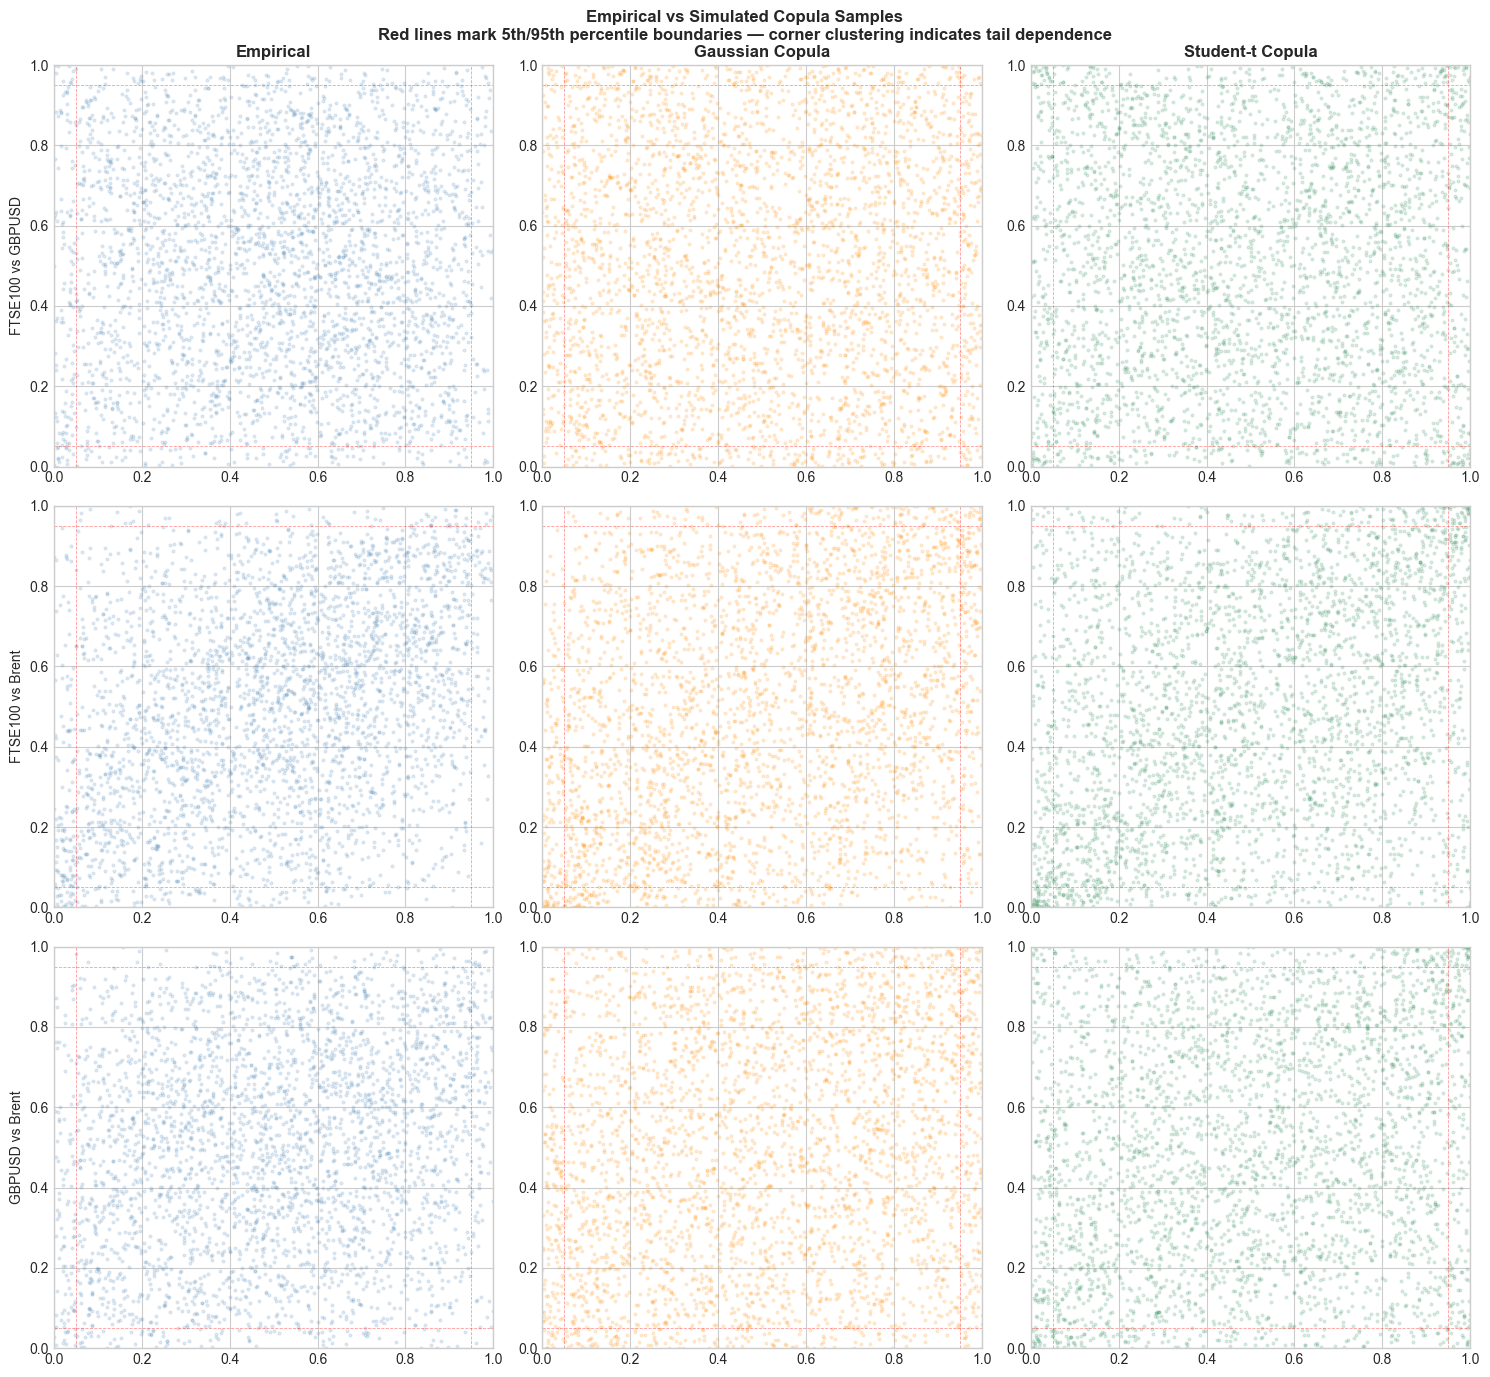

In [11]:
np.random.seed(42)
n_sim = len(uniforms)

gauss_samples = gaussian_copula.simulate(n_sim, seed=42)
t_samples     = student_copula.simulate(n_sim, seed=42)

fig, axes = plt.subplots(3, 3, figsize=(15, 14))

titles   = ['Empirical', 'Gaussian Copula', 'Student-t Copula']
datasets = [uniforms.values, gauss_samples, t_samples]
colors_sim = ['steelblue', 'darkorange', 'seagreen']
row_labels = ['FTSE100 vs GBPUSD', 'FTSE100 vs Brent', 'GBPUSD vs Brent']
index_pairs = [(0, 1), (0, 2), (1, 2)]

for col, (title, data, color) in enumerate(zip(titles, datasets, colors_sim)):
    for row, (a_idx, b_idx) in enumerate(index_pairs):
        axes[row, col].scatter(
            data[:, a_idx], data[:, b_idx],
            alpha=0.15, s=4, color=color
        )
        axes[row, col].set_xlim(0, 1)
        axes[row, col].set_ylim(0, 1)

        # Corner boundary lines
        for val in [0.05, 0.95]:
            axes[row, col].axvline(val, color='red', linewidth=0.6,
                                   linestyle='--', alpha=0.4)
            axes[row, col].axhline(val, color='red', linewidth=0.6,
                                   linestyle='--', alpha=0.4)

        if row == 0:
            axes[row, col].set_title(title, fontsize=12, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(row_labels[row], fontsize=10)

plt.suptitle(
    'Empirical vs Simulated Copula Samples\n'
    'Red lines mark 5th/95th percentile boundaries — '
    'corner clustering indicates tail dependence',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../results/figures/10_copula_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The empirical column (blue, left) is the ground truth. The Gaussian 
column (orange, middle) and Student-t column (green, right) are simulated 
from each fitted copula. A good copula fit should visually resemble 
the empirical scatter.

**Gaussian Copula**
- Points are spread relatively uniformly across the $[0,1]^2$ square
- Corner regions (beyond the red dashed lines) show sparse occupation
- This is the Gaussian copula behaving exactly as expected — it has 
  no mechanism to produce corner clustering
- The FTSE100/Brent panel is the most telling — the Gaussian simulation 
  looks noticeably more uniform than the empirical data

**Student-t Copula**
- Visible corner clustering in all three pair panels — particularly 
  in the bottom-left corner (joint crashes)
- The FTSE100/Brent panel shows the most pronounced corner mass, 
  consistent with its $\lambda = 0.1298$ tail dependence coefficient
- The overall structure more closely resembles the empirical scatter 
  than the Gaussian simulation

**Key observation**
The Student-t copula better replicates the empirical joint behaviour 
in the tails. The Gaussian copula produces a structurally different 
scatter — too uniform in the corners, not enough extreme co-movement.

This visual finding, combined with the AIC improvement of 151.66 and 
the tail dependence coefficients of 5–13%, provides three independent 
lines of evidence that the Student-t copula is the correct model for 
this portfolio.

In [13]:
with open('../data/raw/gaussian_copula.pkl', 'wb') as f:
    pickle.dump(gaussian_copula, f)

with open('../data/raw/student_copula.pkl', 'wb') as f:
    pickle.dump(student_copula, f)